# K-IDS Hybrid Model Training - Ensemble Decision Tree
Training 2 Decision Tree models (syscall + network) untuk hybrid intrusion detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Dataset

In [2]:
# Load 2 datasets: syscall dan network flow
syscall_df = pd.read_csv('../feature_engineering/dataset/syscall_dataset.csv')
network_df = pd.read_csv('../feature_engineering/dataset/network_flow_dataset.csv')

print(f"Syscall dataset shape: {syscall_df.shape}")
print(f"Network dataset shape: {network_df.shape}")

print("\nSyscall features:")
display(syscall_df.head())
print("\nNetwork features:")
display(network_df.head())

Syscall dataset shape: (74303, 7)
Network dataset shape: (128086, 12)

Syscall features:


,pod_name,label,n1,n2,n3,n4,n5
0,flask-postgres-7f55b7f765-88rzs,0,60,60,60,60,60
1,flask-postgres-7f55b7f765-88rzs,0,60,60,60,60,60
2,flask-postgres-7f55b7f765-88rzs,0,60,60,60,60,60
3,flask-postgres-7f55b7f765-88rzs,0,60,60,60,60,60
4,flask-postgres-7f55b7f765-88rzs,0,60,60,60,60,60



Network features:


,proto_TCP,proto_UDP,dir_EGRESS,verdict_FORWARDED,verdict_TRACED,flag_SYN,flag_ACK,flag_FIN,flag_RST,flag_PSH,is_reply,label
0,0,1,1,1,0,0,0,0,0,0,0,0
1,0,1,1,1,0,0,0,0,0,0,0,0
2,1,0,1,1,0,1,0,0,0,0,0,0
3,1,0,1,1,0,1,1,0,0,0,1,0
4,1,0,1,1,0,0,1,0,0,0,0,0


## Exploratory Data Analysis (EDA)

In [3]:
# Info dataset
print("="*50)
print("SYSCALL DATA INFO")
print("="*50)
print(syscall_df.info())

print("\n" + "="*50)
print("NETWORK DATA INFO")
print("="*50)
print(network_df.info())

SYSCALL DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 74303 entries, 0 to 74302
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pod_name  74303 non-null  str  
 1   label     74303 non-null  int64
 2   n1        74303 non-null  int64
 3   n2        74303 non-null  int64
 4   n3        74303 non-null  int64
 5   n4        74303 non-null  int64
 6   n5        74303 non-null  int64
dtypes: int64(6), str(1)
memory usage: 4.0 MB
None

NETWORK DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 128086 entries, 0 to 128085
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   proto_TCP          128086 non-null  int64
 1   proto_UDP          128086 non-null  int64
 2   dir_EGRESS         128086 non-null  int64
 3   verdict_FORWARDED  128086 non-null  int64
 4   verdict_TRACED     128086 non-null  int64
 5   flag_SYN           128086 non-null  int64
 6   f

In [4]:
# Missing values
print("\n" + "="*50)
print("MISSING VALUES - SYSCALL")
print("="*50)
print(syscall_df.isnull().sum())

print("\n" + "="*50)
print("MISSING VALUES - NETWORK")
print("="*50)
print(network_df.isnull().sum())


MISSING VALUES - SYSCALL
pod_name    0
label       0
n1          0
n2          0
n3          0
n4          0
n5          0
dtype: int64

MISSING VALUES - NETWORK
proto_TCP            0
proto_UDP            0
dir_EGRESS           0
verdict_FORWARDED    0
verdict_TRACED       0
flag_SYN             0
flag_ACK             0
flag_FIN             0
flag_RST             0
flag_PSH             0
is_reply             0
label                0
dtype: int64



DISTRIBUSI KELAS
Syscall: label
0    52164
1    22139
Name: count, dtype: int64
Network: label
0    121992
1      6094
Name: count, dtype: int64


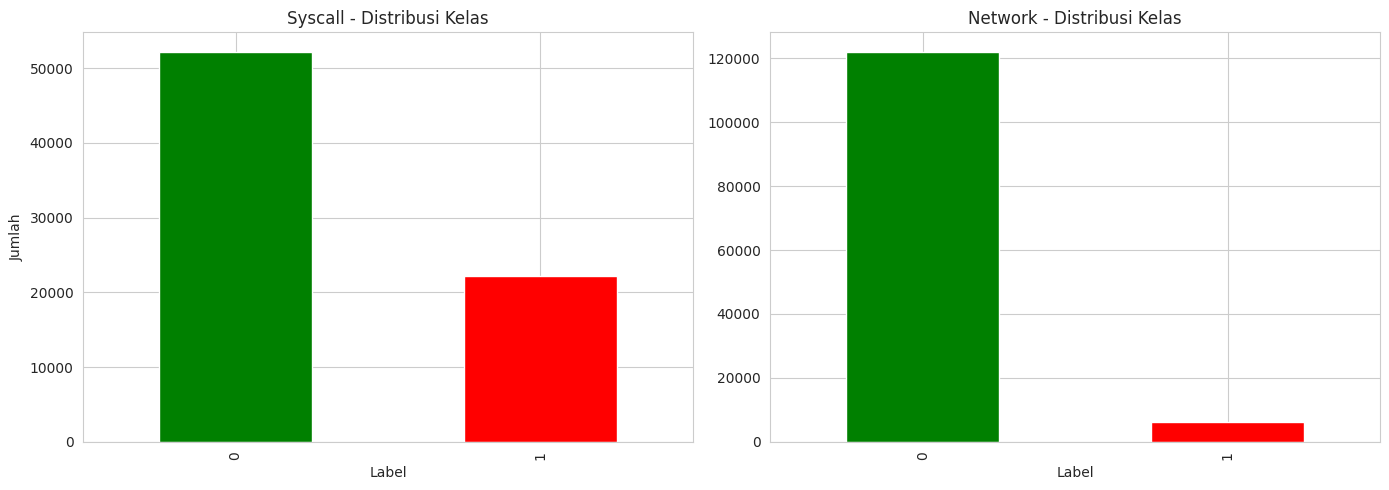

In [5]:
# Distribusi kelas
print("\n" + "="*50)
print("DISTRIBUSI KELAS")
print("="*50)
print("Syscall:", syscall_df['label'].value_counts())
print("Network:", network_df['label'].value_counts())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
syscall_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Syscall - Distribusi Kelas')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah')
network_df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Network - Distribusi Kelas')
axes[1].set_xlabel('Label')
plt.tight_layout()
plt.show()

In [ ]:
# Skip correlation heatmap untuk efisiensi

## Data Preparation

In [6]:
# Pisahkan features dan target untuk kedua dataset
# Drop kolom non-numeric (pod_name, dll)
X_syscall = syscall_df.drop(['label', 'pod_name'], axis=1, errors='ignore')
y_syscall = syscall_df['label']

X_network = network_df.drop(['label', 'pod_name'], axis=1, errors='ignore')
y_network = network_df['label']

print(f"Syscall features: {X_syscall.shape}")
print(f"Network features: {X_network.shape}")

Syscall features: (74303, 5)
Network features: (128086, 11)


In [7]:
# Split data untuk kedua dataset
X_train_sys, X_test_sys, y_train_sys, y_test_sys = train_test_split(
    X_syscall, y_syscall, test_size=0.2, random_state=42, stratify=y_syscall
)

X_train_net, X_test_net, y_train_net, y_test_net = train_test_split(
    X_network, y_network, test_size=0.2, random_state=42, stratify=y_network
)

print(f"Syscall - Train: {X_train_sys.shape}, Test: {X_test_sys.shape}")
print(f"Network - Train: {X_train_net.shape}, Test: {X_test_net.shape}")

Syscall - Train: (59442, 5), Test: (14861, 5)
Network - Train: (102468, 11), Test: (25618, 11)


## Feature Scaling

In [8]:
# Standardize features untuk kedua dataset
scaler_sys = StandardScaler()
X_train_sys_scaled = scaler_sys.fit_transform(X_train_sys)
X_test_sys_scaled = scaler_sys.transform(X_test_sys)

scaler_net = StandardScaler()
X_train_net_scaled = scaler_net.fit_transform(X_train_net)
X_test_net_scaled = scaler_net.transform(X_test_net)

## Handle Imbalanced Data dengan SMOTE

In [9]:
# Apply SMOTE untuk kedua dataset
smote = SMOTE(random_state=42)

print("Syscall - Before SMOTE:", pd.Series(y_train_sys).value_counts().to_dict())
X_train_sys_balanced, y_train_sys_balanced = smote.fit_resample(X_train_sys_scaled, y_train_sys)
print("Syscall - After SMOTE:", pd.Series(y_train_sys_balanced).value_counts().to_dict())

print("\nNetwork - Before SMOTE:", pd.Series(y_train_net).value_counts().to_dict())
X_train_net_balanced, y_train_net_balanced = smote.fit_resample(X_train_net_scaled, y_train_net)
print("Network - After SMOTE:", pd.Series(y_train_net_balanced).value_counts().to_dict())

Syscall - Before SMOTE: {0: 41731, 1: 17711}
Syscall - After SMOTE: {1: 41731, 0: 41731}

Network - Before SMOTE: {0: 97593, 1: 4875}
Network - After SMOTE: {0: 97593, 1: 97593}


## Train Decision Tree Model

In [10]:
# Train 2 Decision Tree models
dt_syscall = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

dt_network = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

print("Training syscall model...")
dt_syscall.fit(X_train_sys_balanced, y_train_sys_balanced)
print("✓ Syscall model trained")

print("Training network model...")
dt_network.fit(X_train_net_balanced, y_train_net_balanced)
print("✓ Network model trained")

Training syscall model...
✓ Syscall model trained
Training network model...
✓ Network model trained


## Model Evaluation

In [12]:
# Predictions dari kedua model
y_pred_sys = dt_syscall.predict(X_test_sys_scaled)
y_pred_net = dt_network.predict(X_test_net_scaled)

# Evaluasi individual models
print("="*50)
print("SYSCALL MODEL")
print("="*50)
acc_sys = accuracy_score(y_test_sys, y_pred_sys)
print(f"Accuracy: {acc_sys:.4f}")
print(classification_report(y_test_sys, y_pred_sys))

print("\n" + "="*50)
print("NETWORK MODEL")
print("="*50)
acc_net = accuracy_score(y_test_net, y_pred_net)
print(f"Accuracy: {acc_net:.4f}")
print(classification_report(y_test_net, y_pred_net))

print("\n" + "="*50)
print("HYBRID DETECTION STRATEGY")
print("="*50)
print("Kedua model bekerja independen:")
print(f"- Syscall model accuracy: {acc_sys:.4f}")
print(f"- Network model accuracy: {acc_net:.4f}")
print("\nPada runtime, alert akan trigger jika salah satu model detect malicious")

SYSCALL MODEL
Accuracy: 0.6380
              precision    recall  f1-score   support

           0       0.78      0.67      0.72     10433
           1       0.42      0.55      0.48      4428

    accuracy                           0.64     14861
   macro avg       0.60      0.61      0.60     14861
weighted avg       0.67      0.64      0.65     14861


NETWORK MODEL
Accuracy: 0.7386
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     24399
           1       0.11      0.65      0.19      1219

    accuracy                           0.74     25618
   macro avg       0.54      0.70      0.52     25618
weighted avg       0.94      0.74      0.81     25618


HYBRID DETECTION STRATEGY
Kedua model bekerja independen:
- Syscall model accuracy: 0.6380
- Network model accuracy: 0.7386

Pada runtime, alert akan trigger jika salah satu model detect malicious


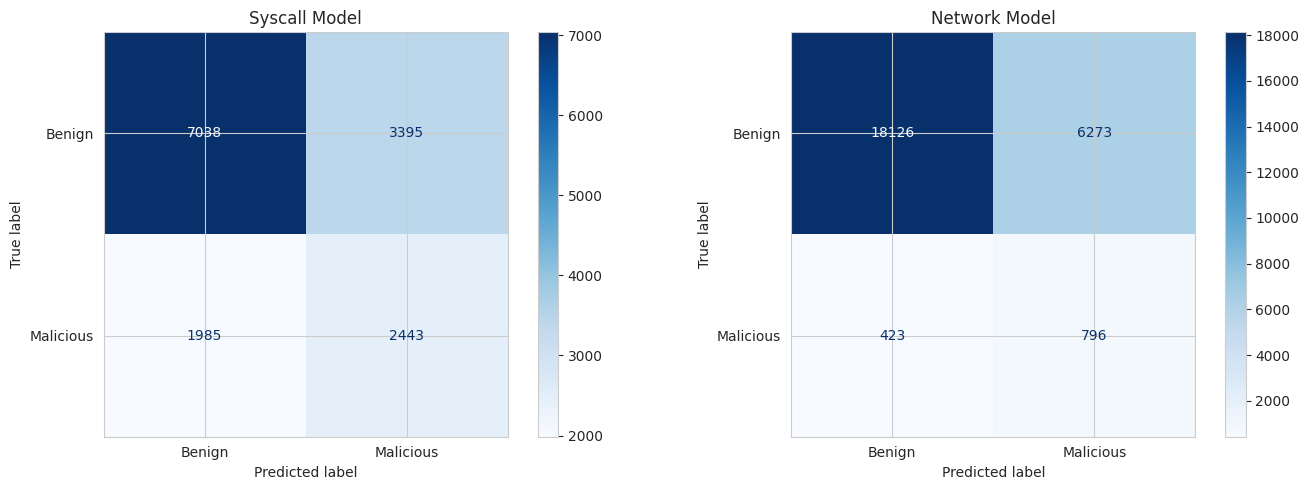

In [13]:
# Confusion Matrix untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_sys = confusion_matrix(y_test_sys, y_pred_sys)
ConfusionMatrixDisplay(cm_sys, display_labels=['Benign', 'Malicious']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Syscall Model')

cm_net = confusion_matrix(y_test_net, y_pred_net)
ConfusionMatrixDisplay(cm_net, display_labels=['Benign', 'Malicious']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Network Model')

plt.tight_layout()
plt.show()

## Feature Importance

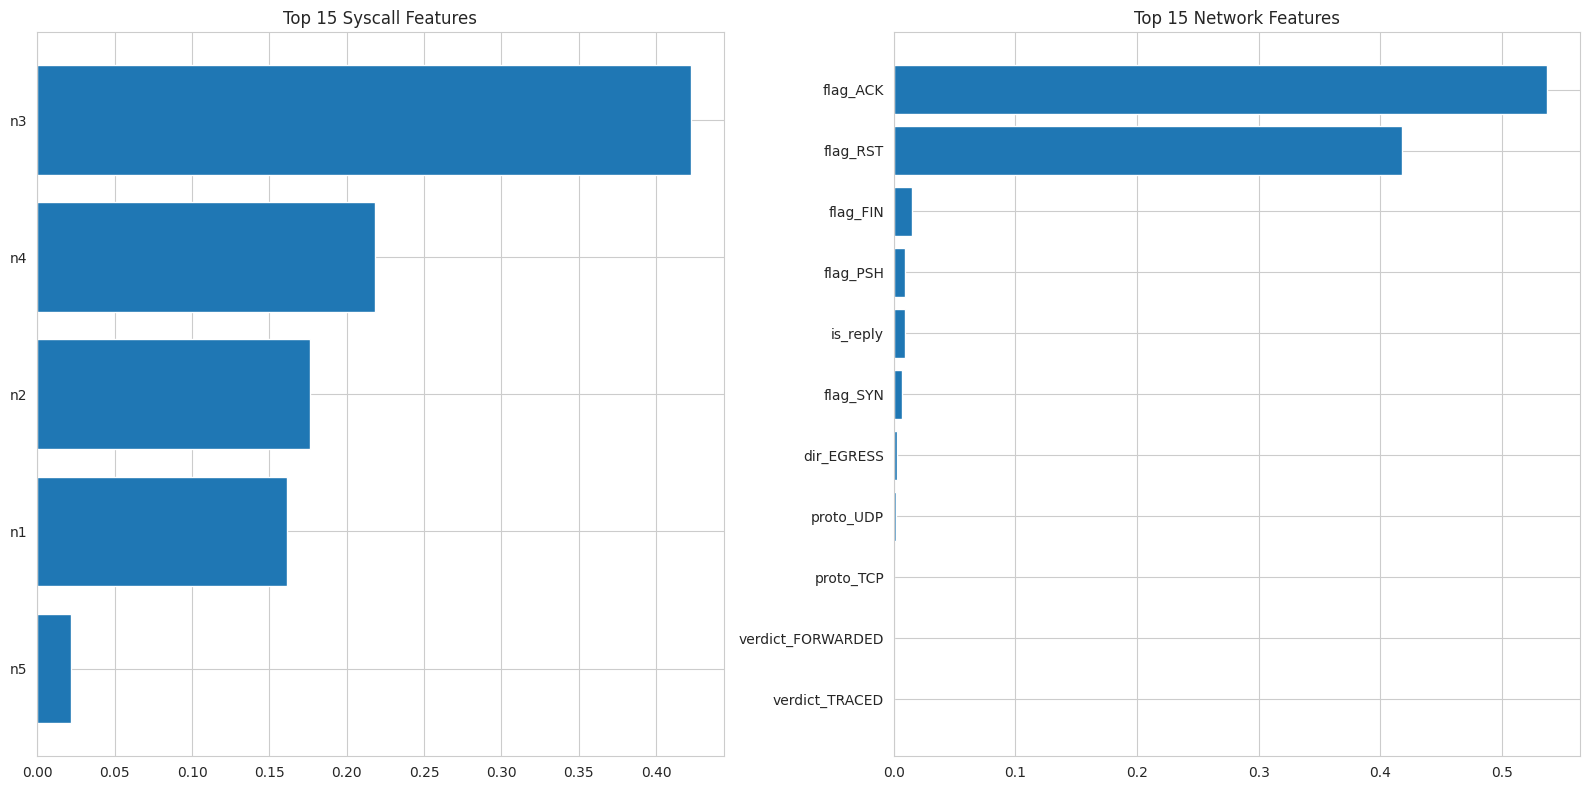

In [14]:
# Feature importance untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Syscall features
fi_sys = pd.DataFrame({'feature': X_syscall.columns, 'importance': dt_syscall.feature_importances_}).sort_values('importance', ascending=False).head(15)
axes[0].barh(range(len(fi_sys)), fi_sys['importance'])
axes[0].set_yticks(range(len(fi_sys)))
axes[0].set_yticklabels(fi_sys['feature'])
axes[0].set_title('Top 15 Syscall Features')
axes[0].invert_yaxis()

# Network features
fi_net = pd.DataFrame({'feature': X_network.columns, 'importance': dt_network.feature_importances_}).sort_values('importance', ascending=False).head(15)
axes[1].barh(range(len(fi_net)), fi_net['importance'])
axes[1].set_yticks(range(len(fi_net)))
axes[1].set_yticklabels(fi_net['feature'])
axes[1].set_title('Top 15 Network Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Visualisasi Decision Tree

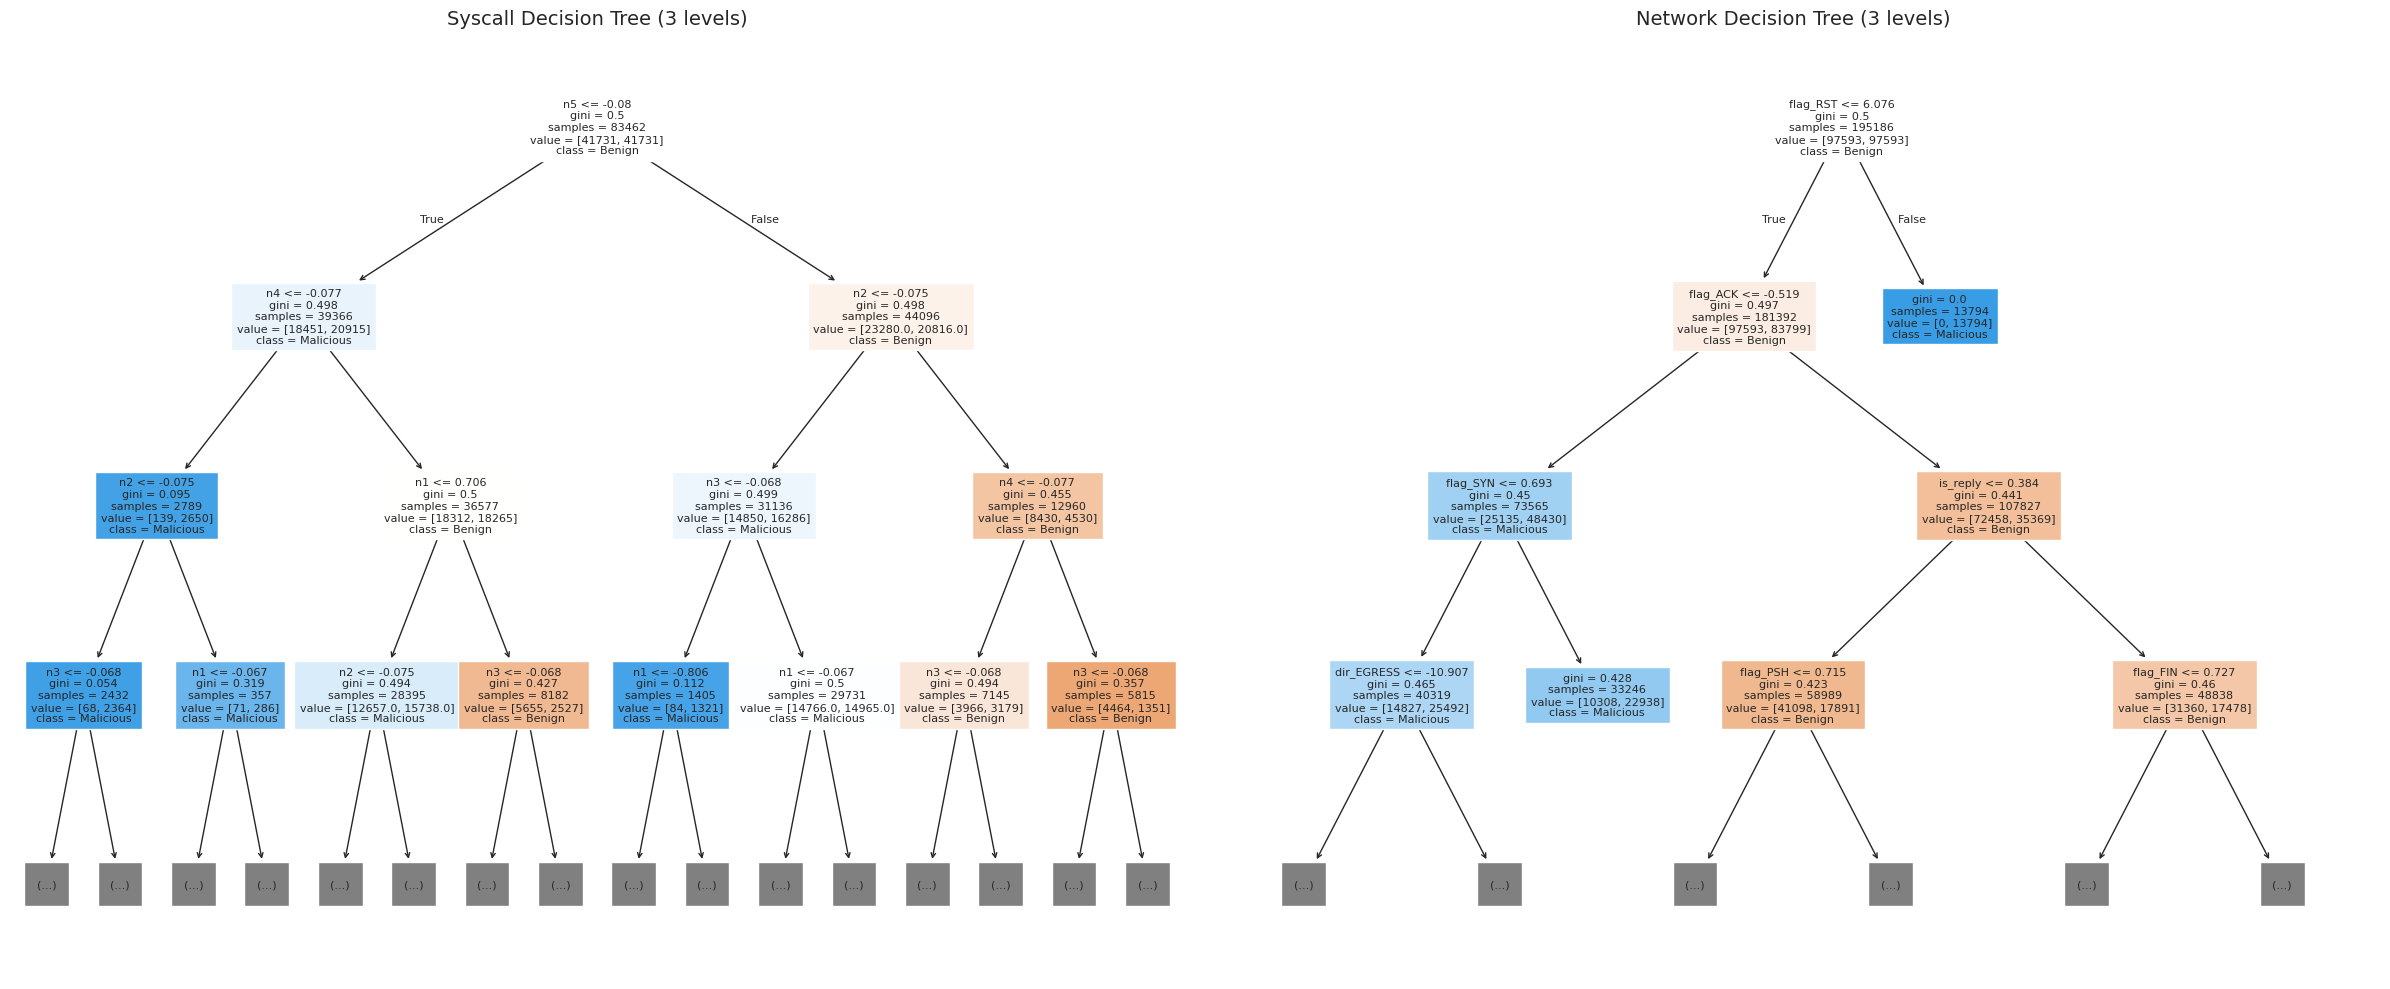

In [15]:
# Visualisasi Decision Tree untuk kedua model
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Syscall tree
plot_tree(dt_syscall, 
          max_depth=3,
          feature_names=X_syscall.columns,
          class_names=['Benign', 'Malicious'],
          filled=True,
          fontsize=8,
          ax=axes[0])
axes[0].set_title('Syscall Decision Tree (3 levels)', fontsize=14)

# Network tree
plot_tree(dt_network, 
          max_depth=3,
          feature_names=X_network.columns,
          class_names=['Benign', 'Malicious'],
          filled=True,
          fontsize=8,
          ax=axes[1])
axes[1].set_title('Network Decision Tree (3 levels)', fontsize=14)

plt.tight_layout()
plt.show()

## Save Model

In [16]:
# Save kedua model dan scaler
joblib.dump(dt_syscall, 'models/dt_syscall_model.pkl')
joblib.dump(dt_network, 'models/dt_network_model.pkl')
joblib.dump(scaler_sys, 'models/scaler_syscall.pkl')
joblib.dump(scaler_net, 'models/scaler_network.pkl')
joblib.dump(X_syscall.columns.tolist(), 'models/feature_names_syscall.pkl')
joblib.dump(X_network.columns.tolist(), 'models/feature_names_network.pkl')

print("✓ Syscall model: models/dt_syscall_model.pkl")
print("✓ Network model: models/dt_network_model.pkl")
print("✓ Scalers dan feature names tersimpan")

✓ Syscall model: models/dt_syscall_model.pkl
✓ Network model: models/dt_network_model.pkl
✓ Scalers dan feature names tersimpan
